In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from dataclasses import dataclass, field
from typing import Dict, Callable, Tuple, List

# --- Configuration & Constants ---
class Config:
    DAILY_INSTALLS_BASE = 20000
    DAILY_INSTALLS_OLD = 12000
    DAILY_INSTALLS_NEW = 8000
    
    ASSUMED_ARPPU = 1.00  # Stated assumption for IAP price
    SWITCH_DAY = 20       # Day when the new user source is added
    SIMULATION_DAYS = 30  # Duration of the analysis

    # Visualization Settings
    FIG_SIZE = (10, 6)
    COLOR_A = '#1f77b4' # Blue
    COLOR_B = '#ff7f0e' # Orange

print("Configuration loaded.")

Configuration loaded.


In [19]:
# --- Mathematical Models ---
def power_law(t, a, b):
    """Power Law: R(t) = a * t^b"""
    return a * np.power(t, b)

def exponential_decay_a(day):
    """New Source Retention Formula for A"""
    return 0.58 * np.exp(-0.12 * (day - 1))

def exponential_decay_b(day):
    """New Source Retention Formula for B"""
    return 0.52 * np.exp(-0.10 * (day - 1))

# --- The Variant Class (Data + Behavior) ---
@dataclass
class Variant:
    name: str
    daily_purchase_ratio: float
    ecpm: float
    ad_imp_dau: float
    known_retention: Dict[int, float]
    # These will be populated after fitting
    retention_model: Dict[int, float] = field(default_factory=dict)
    
    def fit_retention_curve(self, days=30):
        """Fits power law to known data and generates full retention map."""
        x = np.array(list(self.known_retention.keys()))
        y = np.array(list(self.known_retention.values()))
        
        # Fit curve
        popt, _ = curve_fit(power_law, x, y, p0=[0.5, -0.5])
        a, b = popt
        
        # Generate map
        self.retention_model = {0: 1.0}
        for day in range(1, days + 1):
            rate = power_law(day, a, b)
            self.retention_model[day] = max(0.0, min(rate, 1.0))
            
    def get_retention(self, day: int) -> float:
        return self.retention_model.get(day, 0.0)

# --- The Simulator (The Business Logic) ---
class RevenueSimulator:
    
    @staticmethod
    def calculate_dau(variant: Variant, day: int, installs: int) -> float:
        """Standard DAU calculation for a single cohort stream."""
        dau = 0
        for age in range(day + 1):
            dau += installs * variant.get_retention(age)
        return dau

    @staticmethod
    def run_mixed_cohort_simulation(
        variant: Variant, 
        new_retention_func: Callable, 
        config: Config
    ) -> Tuple[float, List[float]]:
        """
        Runs the complex 'New User Source' simulation.
        Returns: (Total Revenue at End, Daily Cumulative Revenue List)
        """
        # Pre-calculate new retention map
        new_retention_map = {0: 1.0}
        for d in range(1, config.SIMULATION_DAYS + 1):
            new_retention_map[d] = max(0.0, min(new_retention_func(d), 1.0))

        cumulative_revenue = 0
        revenue_history = []
        
        total_pre_switch = config.DAILY_INSTALLS_OLD + config.DAILY_INSTALLS_NEW

        for current_day in range(1, config.SIMULATION_DAYS + 1):
            daily_dau = 0
            
            # Sum cohorts based on install date
            for age in range(current_day + 1):
                install_date = current_day - age
                
                if install_date < config.SWITCH_DAY:
                    # Old Regime: All users use original retention
                    users = total_pre_switch * variant.get_retention(age)
                else:
                    # New Regime: Split Traffic
                    users_old = config.DAILY_INSTALLS_OLD * variant.get_retention(age)
                    users_new = config.DAILY_INSTALLS_NEW * new_retention_map[age]
                    users = users_old + users_new
                
                daily_dau += users
            
            # Calculate Daily Revenue
            iap_rev = daily_dau * variant.daily_purchase_ratio * config.ASSUMED_ARPPU
            ad_rev = daily_dau * variant.ad_imp_dau * variant.ecpm / 1000.0
            
            cumulative_revenue += (iap_rev + ad_rev)
            revenue_history.append(cumulative_revenue)
            
        return cumulative_revenue, revenue_history

print("Classes and Models defined.")

Classes and Models defined.


In [32]:
class Visualizer:
    @staticmethod
    def plot_retention_fit(variant: Variant, color):
        """Plots actual data points vs the fitted curve."""
        days = list(variant.retention_model.keys())
        rates = list(variant.retention_model.values())
        
        plt.plot(days, rates, linestyle='--', color=color, alpha=0.7, label=f'{variant.name} (Fit)')
        plt.scatter(list(variant.known_retention.keys()), 
                   list(variant.known_retention.values()), 
                   color=color, s=80, zorder=5, label=f'{variant.name} (Actual)')

    @staticmethod
    def plot_revenue_race(history_a, history_b, title):
        """Plots the cumulative revenue comparison."""
        days = range(1, len(history_a) + 1)
        
        plt.figure(figsize=Config.FIG_SIZE)
        plt.plot(days, history_a, label='Variant A', color=Config.COLOR_A, linewidth=2)
        plt.plot(days, history_b, label='Variant B', color=Config.COLOR_B, linewidth=2)
        
        # Highlight the gap
        plt.fill_between(days, history_a, history_b, color='gray', alpha=0.1)
        
        plt.title(title, fontsize=14)
        plt.xlabel('Days Since Launch', fontsize=12)
        plt.ylabel('Cumulative Revenue ($)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    @staticmethod
    def plot_dau_trend(days, dau_trend_a, dau_trend_b):
        """Plots the DAU trend for both variants over a range of days."""
        plt.figure(figsize=Config.FIG_SIZE)
        plt.plot(days, dau_trend_a, label='Variant A', color=Config.COLOR_A)
        plt.plot(days, dau_trend_b, label='Variant B', color=Config.COLOR_B)
        plt.title("Daily Active Users (DAU) Projection")
        plt.xlabel("Day")
        plt.ylabel("Active Users")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


    @staticmethod
    def plot_bar_comparison(labels, base_values, comparison_values, base_label, comparison_label, title, ylabel):
        """
        Plots a bar chart comparing two sets of values (e.g., base vs. comparison).
        
        Args:
            labels (List[str]): Labels for the x-axis (e.g., ['Variant A', 'Variant B']).
            base_values (List[float]): Values for the base scenario.
            comparison_values (List[float]): Values for the comparison scenario.
            base_label (str): Label for the base scenario.
            comparison_label (str): Label for the comparison scenario.
            title (str): Title of the plot.
            ylabel (str): Label for the y-axis.
        """
        x = range(len(labels))
        width = 0.35

        plt.figure(figsize=Config.FIG_SIZE)
        plt.bar([i - width / 2 for i in x], base_values, width, label=base_label, color=Config.COLOR_A)
        plt.bar([i + width / 2 for i in x], comparison_values, width, label=comparison_label, color='green')
        plt.xticks(x, labels)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.show()

    @staticmethod
    def plot_option_comparison(options: Dict[str, float], title: str, ylabel: str):
        """
        Plots a bar chart comparing multiple options.

        Args:
            options (Dict[str, float]): A dictionary where keys are option names and values are revenues.
            title (str): Title of the plot.
            ylabel (str): Label for the y-axis.
        """
        labels = list(options.keys())
        values = list(options.values())
        colors = ['gray', 'green', 'blue']  # Customize colors for each bar

        plt.figure(figsize=Config.FIG_SIZE)
        bars = plt.bar(labels, values, color=colors)
        plt.title(title, fontsize=14)
        plt.ylabel(ylabel, fontsize=12)
        plt.ylim(min(values) * 0.95, max(values) * 1.05)

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2., height,
                     f'${int(height):,}',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

        plt.grid(axis='y', alpha=0.3)
        plt.show()

----

A)

--- Task (a): DAU at Day 15 ---
Variant A: 74,685 users
Variant B: 76,474 users
WINNER: Variant B


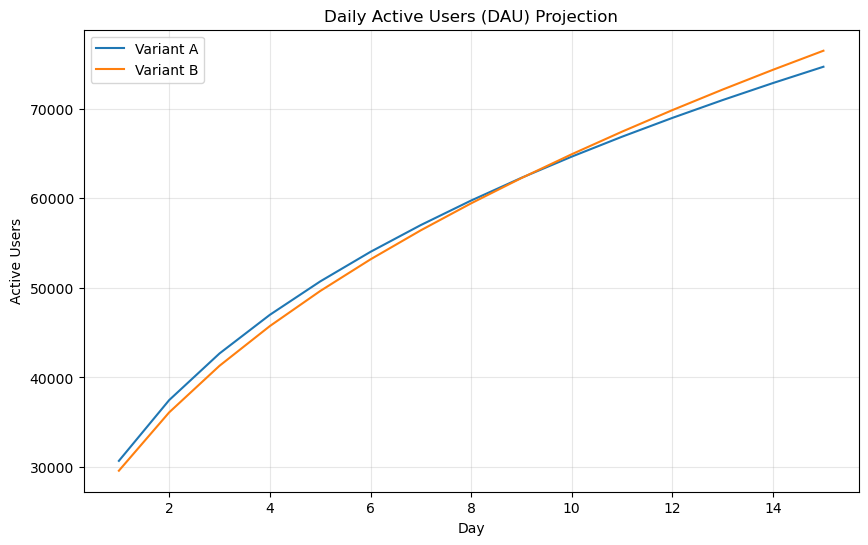

In [ ]:
# 1. Initialize the Variants (Data from Prompt)
var_a = Variant("Variant A", 0.0305, 9.80, 2.3, {1: 0.53, 3: 0.27, 7: 0.17, 14: 0.06})
var_b = Variant("Variant B", 0.0315, 10.80, 1.6, {1: 0.48, 3: 0.25, 7: 0.19, 14: 0.09})

# 2. Fit the Retention Models (The Engine doing the work)
var_a.fit_retention_curve()
var_b.fit_retention_curve()

# 3. Calculate DAU at Day 15
day_target = 15
dau_a = RevenueSimulator.calculate_dau(var_a, day_target, Config.DAILY_INSTALLS_BASE)
dau_b = RevenueSimulator.calculate_dau(var_b, day_target, Config.DAILY_INSTALLS_BASE)

# 4. Output Results
print(f"--- Task (a): DAU at Day {day_target} ---")
print(f"{var_a.name}: {int(dau_a):,} users")
print(f"{var_b.name}: {int(dau_b):,} users")
print(f"WINNER: {var_b.name if dau_b > dau_a else var_a.name}")

# 5. Visualize DAU Trend (Day 1-15)
days = range(1, 16)
dau_trend_a = [RevenueSimulator.calculate_dau(var_a, d, Config.DAILY_INSTALLS_BASE) for d in days]
dau_trend_b = [RevenueSimulator.calculate_dau(var_b, d, Config.DAILY_INSTALLS_BASE) for d in days]

# Use the Visualizer class to plot the DAU trend
Visualizer.plot_dau_trend(days, dau_trend_a, dau_trend_b)

B)

--- Task (b): Total Revenue by Day 15 ---
Variant A: $45,649.09
Variant B: $41,895.33
WINNER: Variant A


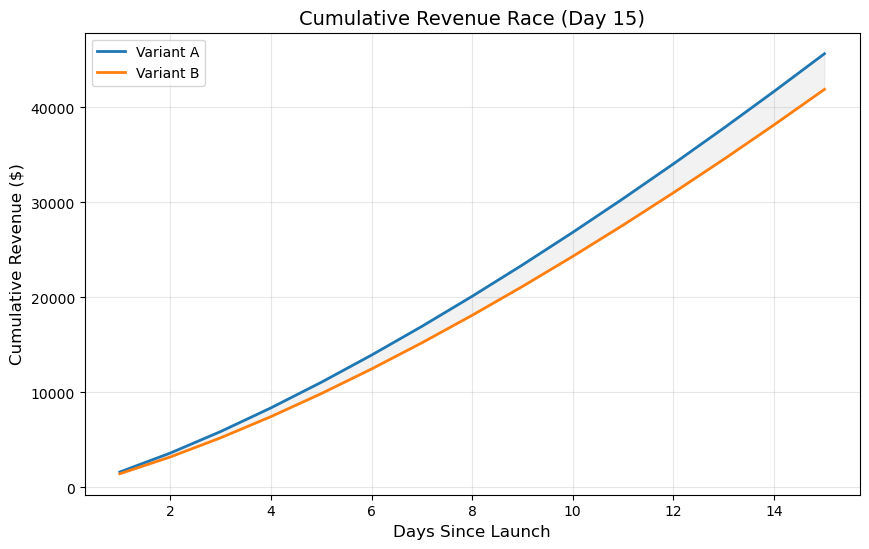

In [25]:
def run_basic_revenue_sim(variant, days):
    """Helper to calculate cumulative revenue for standard conditions."""
    cumulative = 0
    history = []
    for d in range(1, days + 1):
        dau = RevenueSimulator.calculate_dau(variant, d, Config.DAILY_INSTALLS_BASE)
        # Revenue Formulas
        iap = dau * variant.daily_purchase_ratio * Config.ASSUMED_ARPPU
        ad = dau * variant.ad_imp_dau * variant.ecpm / 1000.0
        cumulative += (iap + ad)
        history.append(cumulative)
    return cumulative, history

# Run for 15 Days
rev_a_15, hist_a_15 = run_basic_revenue_sim(var_a, 15)
rev_b_15, hist_b_15 = run_basic_revenue_sim(var_b, 15)

print(f"--- Task (b): Total Revenue by Day 15 ---")
print(f"{var_a.name}: ${rev_a_15:,.2f}")
print(f"{var_b.name}: ${rev_b_15:,.2f}")
print(f"WINNER: {var_a.name if rev_a_15 > rev_b_15 else var_b.name}")

# Visualize
Visualizer.plot_revenue_race(hist_a_15, hist_b_15, "Cumulative Revenue Race (Day 15)")

C)

--- Task (c): Total Revenue by Day 30 ---
Variant A: $114,585.70
Variant B: $108,381.09
WINNER: Variant A


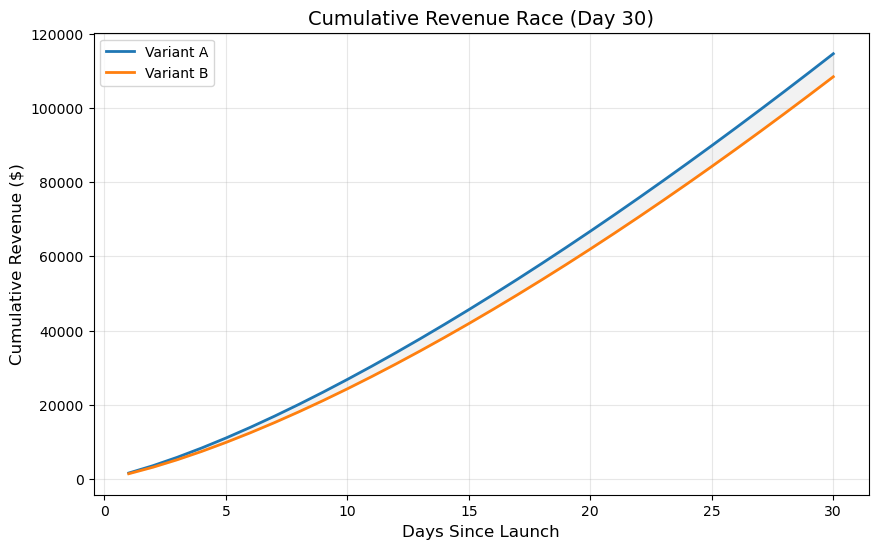

In [26]:
# Run for 30 Days
rev_a_30, hist_a_30 = run_basic_revenue_sim(var_a, 30)
rev_b_30, hist_b_30 = run_basic_revenue_sim(var_b, 30)

print(f"--- Task (c): Total Revenue by Day 30 ---")
print(f"{var_a.name}: ${rev_a_30:,.2f}")
print(f"{var_b.name}: ${rev_b_30:,.2f}")
print(f"WINNER: {var_a.name if rev_a_30 > rev_b_30 else var_b.name}")

# Visualize
Visualizer.plot_revenue_race(hist_a_30, hist_b_30, "Cumulative Revenue Race (Day 30)")

D)

--- Task (d): Revenue with 10-Day Sale (Day 30) ---
Variant A (Sale): $122,767.21
Variant B (Sale): $116,879.20
WINNER: Variant A


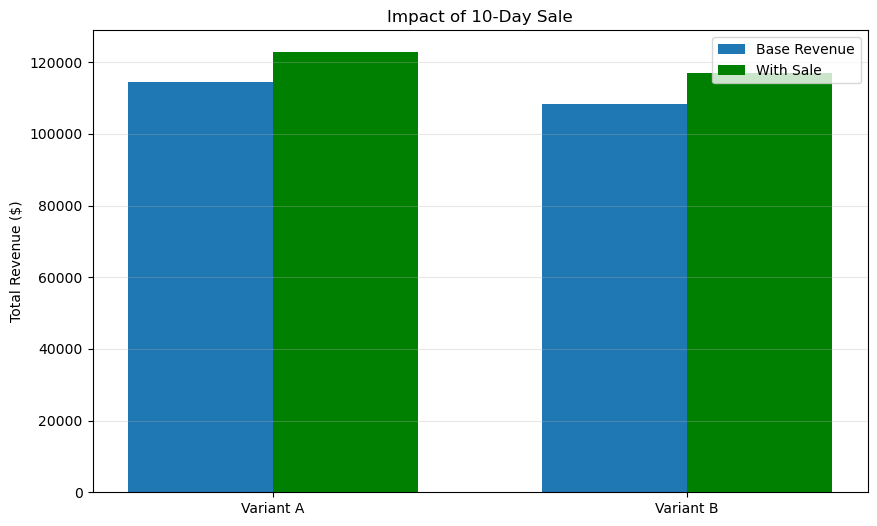

In [29]:
# --- Cell 7: Task (d) The 10-Day Sale ---

def run_sale_simulation(variant, sale_start=15, sale_duration=10):
    cumulative = 0
    sale_end = sale_start + sale_duration - 1  # Days 15 to 24 inclusive
    
    for d in range(1, 31):
        dau = RevenueSimulator.calculate_dau(variant, d, Config.DAILY_INSTALLS_BASE)
        
        # Apply Sale Logic
        current_purchase_ratio = variant.daily_purchase_ratio
        if sale_start <= d <= sale_end:
            current_purchase_ratio += 0.01  # +1% boost
            
        iap = dau * current_purchase_ratio * Config.ASSUMED_ARPPU
        ad = dau * variant.ad_imp_dau * variant.ecpm / 1000.0
        cumulative += (iap + ad)
    return cumulative

# Calculate revenue with the 10-day sale
sale_rev_a = run_sale_simulation(var_a)
sale_rev_b = run_sale_simulation(var_b)

print(f"--- Task (d): Revenue with 10-Day Sale (Day 30) ---")
print(f"{var_a.name} (Sale): ${sale_rev_a:,.2f}")
print(f"{var_b.name} (Sale): ${sale_rev_b:,.2f}")
print(f"WINNER: {var_a.name if sale_rev_a > sale_rev_b else var_b.name}")

# Use the Visualizer to plot the comparison
labels = ['Variant A', 'Variant B']
base_revs = [rev_a_30, rev_b_30]  # From Task (c)
sale_revs = [sale_rev_a, sale_rev_b]

Visualizer.plot_bar_comparison(
    labels=labels,
    base_values=base_revs,
    comparison_values=sale_revs,
    base_label='Base Revenue',
    comparison_label='With Sale',
    title='Impact of 10-Day Sale',
    ylabel='Total Revenue ($)'
)

E)

--- Task (e): Revenue with New User Source (Day 30) ---
Variant A: $117,923.03
Variant B: $111,062.17
WINNER: Variant A


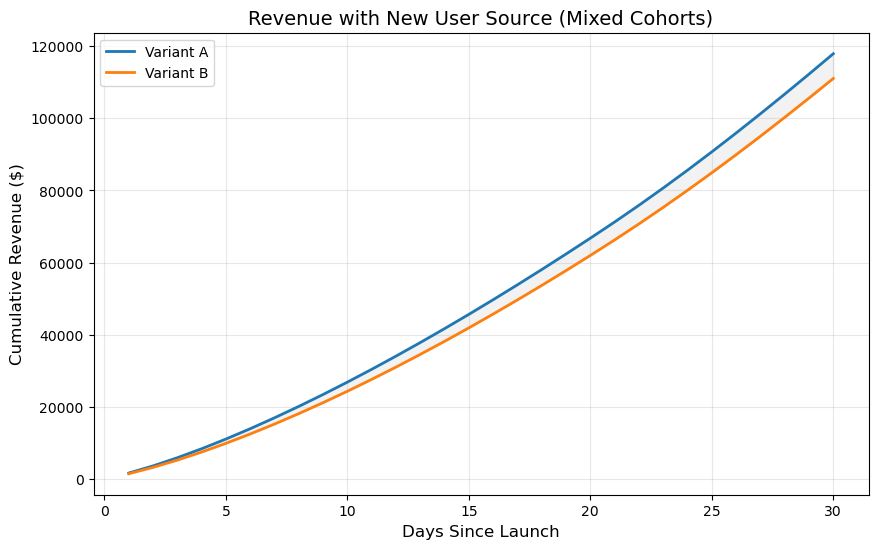

In [30]:
# Define the formulae from the prompt
def new_retention_a(day):
    return 0.58 * np.exp(-0.12 * (day - 1))

def new_retention_b(day):
    return 0.52 * np.exp(-0.10 * (day - 1))

# Run the complex simulation
rev_a_new, hist_a_new = RevenueSimulator.run_mixed_cohort_simulation(var_a, new_retention_a, Config)
rev_b_new, hist_b_new = RevenueSimulator.run_mixed_cohort_simulation(var_b, new_retention_b, Config)

print(f"--- Task (e): Revenue with New User Source (Day 30) ---")
print(f"{var_a.name}: ${rev_a_new:,.2f}")
print(f"{var_b.name}: ${rev_b_new:,.2f}")
print(f"WINNER: {var_a.name if rev_a_new > rev_b_new else var_b.name}")

# Visualize the race
Visualizer.plot_revenue_race(hist_a_new, hist_b_new, "Revenue with New User Source (Mixed Cohorts)")

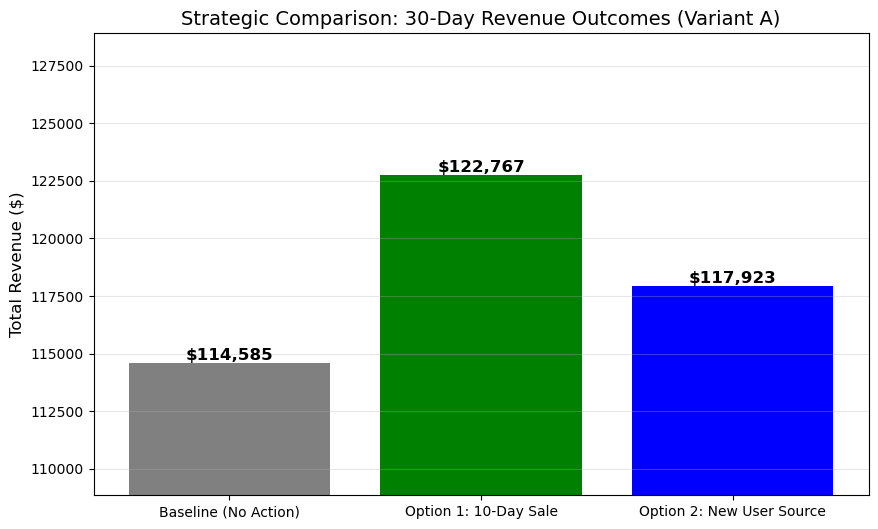

In [34]:
# Data Collection for Decision
options = {
    "Baseline (No Action)": rev_a_30,
    "Option 1: 10-Day Sale": sale_rev_a,
    "Option 2: New User Source": rev_a_new
}

# 1. Visualize the Options
Visualizer.plot_option_comparison(
    options=options,
    title="Strategic Comparison: 30-Day Revenue Outcomes (Variant A)",
    ylabel="Total Revenue ($)"
)

STRATEGIC RECOMMENDATION:
1. Short Term Winner: The 10-Day Sale generates the highest 30-day revenue ($122,767).
2. Long Term Winner: The New User Source ($117,923).

DECISION: Prioritize the NEW USER SOURCE.
Reasoning:
- The Sale is a temporary event. Once it ends on Day 24, revenue per user reverts to baseline.
- The New Source improves retention permanently. While it generates slightly less cash
  in the first 30 days (due to the late start on Day 20), its compound value (LTV)
  will surpass the sale significantly in Months 2 and 3.